### Correcting Selection Bias with IPW and Doubly Robust Estimation
## Abstract

Estimating causal effects from observational data is challenging due to selection bias in treatment assignment. In marketing settings, customers who receive interventions are often systematically different from those who do not, leading to misleading conclusions under naive comparisons.

This post explores practical approaches to correcting this bias using propensity score methods, including Inverse Propensity Weighting (IPW) and Doubly Robust estimation. The focus is on understanding how these methods behave in realistic settings and how they support reliable decision-making.

---

### The problem

In real-world marketing, we often want to answer a causal question:

> **Does sending a marketing email actually increase customer spend or conversion?**

This is not the same as:

> “Do customers who receive emails spend more?”

Because email targeting is **not random**:
- More engaged customers are more likely to be targeted  
- That creates **selection bias**  
- Naive comparisons will overstate impact  

---

### What this analysis does

This analysis walks through how to correct that bias using practical causal methods.

We compare multiple approaches—from simple to robust—to understand:

- how each method adjusts for selection bias  
- when it works well  
- when it breaks  

---

### Methods covered

We implement and compare:

1. **Naive regression** — illustrates bias  
2. **Inverse Propensity Weighting (IPW)** — reweights data to simulate randomization  
3. **Outcome regression** — model-based correction  
4. **Doubly Robust (AIPW)** — combines both for stability  
5. **Conceptual Double ML** — extends DR to ML settings  

For each method, we focus on:

- underlying assumptions  
- practical behavior  
- failure modes  

---

### Dataset

We use the **Hillstrom (MineThatData) Email Marketing dataset**, a public benchmark that closely mirrors real-world targeting scenarios.

- Each row = customer  
- Treatment = received email (1) or not (0)  
- Outcomes = spend and conversion  
- Features = customer history, recency, channel behavior  

---

### Why this matters

In practice, decisions like:
- who to target  
- how to allocate budget  
- which campaigns to scale  

depend on **causal impact—not correlation**.

The goal is not just to estimate effects, but to build intuition for when those estimates can be trusted.

---

## References

- Facure, M. *Causal Inference for the Brave and True*  
  https://matheusfacure.github.io/python-causality-handbook/


In [28]:
# === Standard imports ===
# We keep models simple and interpretable on purpose.
# This analysis is about *causality*, not model tuning.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score

np.random.seed(42)


In [29]:
# === Load the Hillstrom dataset (public) ===
# If this fails due to network restrictions, download the CSV manually
# and set DATA_PATH accordingly.


import pathlib, urllib.request

DATA_DIR = pathlib.Path("data")
DATA_DIR.mkdir(exist_ok=True)
DATA_PATH = DATA_DIR / "hillstrom.csv"

URL = "https://raw.githubusercontent.com/W-Tran/uplift-modelling/master/data/hillstrom/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"

if not DATA_PATH.exists():
    urllib.request.urlretrieve(URL, DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.head()


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [30]:
# === Define treatment, outcome, and covariates ===


df = df.copy()
# Treatment: received any email vs none
# Treatment: received any email vs none
df["T"] = (df["segment"].str.lower() != "no e-mail").astype(int)
# Outcomes
# Outcomes
df["Y_spend"] = df["spend"].astype(float)
df["Y_conv"] = df["conversion"].astype(int)
# Covariates (chosen to reflect realistic marketing features)
# Covariates (chosen to reflect realistic marketing features)
covariates = [
    "recency", "history", "history_segment",
    "mens", "womens", "zip_code", "newbie", "channel"
]

df[covariates + ["T", "Y_spend", "Y_conv"]].head()


,recency,history,history_segment,mens,womens,zip_code,newbie,channel,T,Y_spend,Y_conv
0,10,142.44,2) $100 - $200,1,0,Surburban,0,Phone,1,0.0,0
1,6,329.08,3) $200 - $350,1,1,Rural,1,Web,0,0.0,0
2,7,180.65,2) $100 - $200,0,1,Surburban,1,Web,1,0.0,0
3,9,675.83,5) $500 - $750,1,0,Rural,1,Web,1,0.0,0
4,2,45.34,1) $0 - $100,1,0,Urban,0,Web,1,0.0,0


## Step 1 — Why naive analysis fails

We start with the *wrong* approach on purpose.

If we simply compare:
- average spend of emailed customers
- vs non-emailed customers

we are implicitly assuming **random assignment**.

That assumption is false in observational marketing data.

👉 This step is crucial for storytelling:  
it shows stakeholders *why* causal methods are needed.


In [31]:
# === Naive comparison (intentionally biased) ===


naive_spend = df.groupby("T")["Y_spend"].mean()
naive_conv  = df.groupby("T")["Y_conv"].mean()

print("Naive spend difference:", naive_spend[1] - naive_spend[0])
print("Naive conversion difference:", naive_conv[1] - naive_conv[0])
# Interpretation:
# This looks like a treatment effect,
# but it mixes true causal impact with selection bias.



Naive spend difference: 0.5967960667278982
Naive conversion difference: 0.004954571155268468


## Step 2 — Propensity Scores 

The **propensity score** is:

\[
e(X) = P(T=1 | X)
\]

Plain English:
> “Given what we know about a customer, how likely were they to be emailed?”

Why this matters:
- Customers with the same propensity score are comparable
- Conditioning on the propensity score balances *all* covariates

This is the foundation of IPW and DR.


In [32]:
# === Propensity score model ===


X = df[covariates]
T = df["T"].values

num_cols = [c for c in covariates if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = [c for c in covariates if c not in num_cols]

preprocess = ColumnTransformer(
    [
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

ps_model = Pipeline(
    [
        ("prep", preprocess),
        ("logit", LogisticRegression(max_iter=2000)),
    ]
)

X_train, X_test, T_train, T_test = train_test_split(
    X, T, test_size=0.3, stratify=T, random_state=42
)

ps_model.fit(X_train, T_train)
e_hat = ps_model.predict_proba(X_test)[:, 1]

print("Propensity AUC:", roc_auc_score(T_test, e_hat))


Propensity AUC: 0.49176685713090773


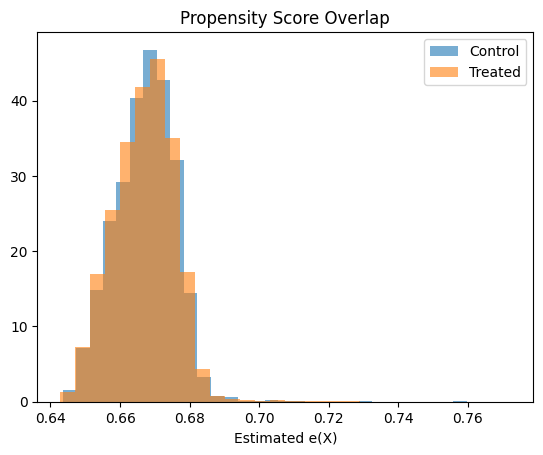

In [35]:
# === Overlap / positivity check ===


plt.hist(e_hat[T_test == 0], bins=30, alpha=0.6, label="Control", density=True)
plt.hist(e_hat[T_test == 1], bins=30, alpha=0.6, label="Treated", density=True)
plt.legend()
plt.title("Propensity Score Overlap")
plt.xlabel("Estimated e(X)")
plt.show()
# Interpretation:
# Good overlap → IPW is feasible
# Poor overlap → expect unstable weights



## Step 3 — IPW (Inverse Propensity Weighting)

**Core idea**

Instead of changing the model, we change the *importance* of observations.

- Customers who were **unlikely to be emailed but were emailed** → get large weight
- Customers who were **very likely to be emailed** → get small weight

This creates a **pseudo-randomized dataset**.

**Key assumption**
- The propensity model is correct


In [38]:
# === IPW estimator ===


def ipw_ate(y, t, e, stabilized=False):
    eps = 1e-6
    e = np.clip(e, eps, 1 - eps)

    if stabilized:
        p = t.mean()
        w = np.where(t == 1, p / e, (1 - p) / (1 - e))
    else:
        w = np.where(t == 1, 1 / e, 1 / (1 - e))

    ate = (
        np.sum(w[t == 1] * y[t == 1]) / np.sum(w[t == 1])
        - np.sum(w[t == 0] * y[t == 0]) / np.sum(w[t == 0])
    )
    return ate, w

Y = df.loc[X_test.index, "Y_spend"].values

ate_ipw, w_raw = ipw_ate(Y, T_test, e_hat, stabilized=False)
ate_ipw_stab, w_stab = ipw_ate(Y, T_test, e_hat, stabilized=True)

print("IPW ATE:", ate_ipw)
print("Stabilized IPW ATE:", ate_ipw_stab)


IPW ATE: 0.6869934772562071
Stabilized IPW ATE: 0.6869934772562072


## Step 4 — Why IPW can be dangerous

IPW can fail badly when:
- Some customers have propensity scores near 0 or 1
- Weights explode
- A few customers dominate the estimate

We will:
- Inspect weight distributions
- Compute effective sample size (ESS)
- Apply stabilization and clipping

This is *mandatory* in real work.


In [39]:
# === Weight diagnostics ===


def ess(w):
    return (w.sum() ** 2) / (w ** 2).sum()

print("Max raw weight:", w_raw.max())
print("ESS raw:", ess(w_raw))
print("ESS stabilized:", ess(w_stab))
# Interpretation:
# Stabilization usually increases ESS dramatically



Max raw weight: 4.160191208753913
ESS raw: 17043.204198395597
ESS stabilized: 19193.43392200713


## Step 5 — Doubly Robust Estimation (AIPW)

Doubly Robust combines:
1. A **propensity model** (design-based)
2. An **outcome model** (model-based)

**Why it’s powerful**
- If *either* model is correct → estimate is consistent
- You get two chances to be right

This is why DR is the default choice in practice.


In [40]:
# === Outcome regression ===


outcome_model = Pipeline(
    [
        ("prep", preprocess),
        ("lr", LinearRegression()),
    ]
)

outcome_model.fit(
    pd.concat([X_train, pd.Series(T_train,index=X_train.index, name="T")], axis=1),
    df.loc[X_train.index, "Y_spend"],
)
# Simpler demonstration:
# Separate models by treatment group


m1 = LinearRegression().fit(
    preprocess.fit_transform(X_train[T_train == 1]),
    df.loc[X_train.index[T_train == 1], "Y_spend"]
)

m0 = LinearRegression().fit(
    preprocess.fit_transform(X_train[T_train == 0]),
    df.loc[X_train.index[T_train == 0], "Y_spend"]
)

m1_hat = m1.predict(preprocess.transform(X_test))
m0_hat = m0.predict(preprocess.transform(X_test))

ate_or = (m1_hat - m0_hat).mean()
print("Outcome regression ATE:", ate_or)


Outcome regression ATE: 0.5598623633614704


In [42]:
# === Doubly Robust / AIPW ===


def aipw_ate(y, t, e, m0, m1):
    eps = 1e-6
    e = np.clip(e, eps, 1 - eps)
    return np.mean(
        (m1 - m0)
        + t * (y - m1) / e
        - (1 - t) * (y - m0) / (1 - e)
    )

ate_dr = aipw_ate(Y, T_test, e_hat, m0_hat, m1_hat)
print("Doubly Robust ATE:", ate_dr)
# Interpretation:
# If either the propensity model OR outcome model is correct,
# this estimate is consistent.



Doubly Robust ATE: 0.6886373812888652


## Final Summary (what to remember)

- **Naive comparison** overstates the effect due to selection bias  
- **Outcome regression** provides a model-based correction but can be sensitive to misspecification  
- **IPW** reweights the data to simulate randomization and performs well when overlap is good  
- **Doubly Robust (DR)** combines both approaches and remains consistent if either model is correct  

### What we observed in this dataset

- Naive estimate: ~0.59  
- Outcome regression: ~0.56  
- IPW: ~0.69  
- Doubly Robust: ~0.69  

Two important insights emerge:

1. **IPW and DR agree closely**, suggesting the propensity model is reliable  
2. **Regression differs**, indicating potential outcome model misspecification  

Additionally:

- Propensity AUC is ~0.49 → treatment assignment is only weakly predictable  
- Overlap is strong → IPW weights remain stable  
- Effective sample size is high → no dominance from extreme weights  

### Practical takeaway

> **Doubly Robust is the safest default in observational settings**—but diagnostics matter.

Even when DR works well:

- Check overlap  
- Inspect weight stability  
- Compare across methods  

**When treatment assignment is weakly predictable and overlap is strong, IPW and DR tend to converge—providing a useful internal consistency check.**

Consistency across estimators is often the strongest signal that your causal estimate is trustworthy.

### Where Double ML fits

Double ML builds on DR by:

- allowing flexible ML models  
- reducing overfitting via cross-fitting  
- improving robustness in high-dimensional settings  

Think of it as:

> **DR + modern ML, done carefully**
